In [63]:
ATHLETE_NAME   = 'Ciulavu'
AGE            = 22
DATA_DIR       = '../data/Ciulavu'
OUT_DIR        = f'../data/analysis_{ATHLETE_NAME}'
RUNNING_SPORTS = {'running', 'trail_running'}

ZONE_BOUNDS = [0.00, 0.60, 0.70, 0.80, 0.90, 1.01]
ZONE_LABELS = ['Z1 Recovery', 'Z2 Aerobic', 'Z3 Tempo', 'Z4 Threshold', 'Z5 VO2max']
ZONE_COLORS = ['#4FC3F7', '#81C784', '#FFD54F', '#FF8A65', '#E57373']

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Athlete: {ATHLETE_NAME}  |  Age: {AGE}')

Athlete: Ciulavu  |  Age: 22


In [64]:
sessions = pd.read_parquet(f'{DATA_DIR}/sessions.parquet')
records  = pd.read_parquet(f'{DATA_DIR}/records.parquet')

runs    = sessions[sessions['sport'].isin(RUNNING_SPORTS)].copy()
run_ids = set(runs['session_id'])
run_rec = records[records['session_id'].isin(run_ids)].copy()

# ── Estimate MAX_HR ──────────────────────────────────────────────────────────
# Primary: 99th percentile of raw HR across all running records.
# At this sample size, sits above noise but below extreme outlier spikes.
formula_hr = round(211 - 0.64 * AGE)
data_hr    = int(run_rec['heart_rate'].quantile(0.99))

# Sanity check: if data estimate is >10 bpm below the formula, the dataset
# likely contains no hard efforts — fall back to the formula.
if data_hr >= formula_hr - 10:
    MAX_HR = data_hr
    hr_source = 'data (99th percentile)'
else:
    MAX_HR = formula_hr
    hr_source = f'formula fallback — data 99th pct ({data_hr} bpm) is >10 below formula'

print(f'Running sessions : {len(runs)}')
print(f'Running records  : {len(run_rec):,}')
print(f'Date range       : {runs["date"].min().date()} → {runs["date"].max().date()}')
print(f'Formula max HR   : {formula_hr} bpm  (211 - 0.64 × {AGE})')
print(f'Data 99th pct    : {data_hr} bpm')
print(f'Using MAX_HR     = {MAX_HR} bpm  [{hr_source}]')

Running sessions : 56
Running records  : 153,268
Date range       : 2025-08-11 → 2026-04-18
Formula max HR   : 197 bpm  (211 - 0.64 × 22)
Data 99th pct    : 185 bpm
Using MAX_HR     = 197 bpm  [formula fallback — data 99th pct (185 bpm) is >10 below formula]


## HR zones vs Speed

In [65]:
# ── Session-level aggregation ────────────────────────────────────────────────
# Strip first 120s of each session (cardiac lag), then compute per-session
# mean HR and mean speed. One row per run — avoids intra-session noise.
def summarise_session(grp):
    grp = grp.sort_values('timestamp')
    t0  = grp['timestamp'].min()
    grp = grp[grp['timestamp'] >= t0 + pd.Timedelta(seconds=120)]
    grp = grp[grp['speed_ms'] >= 1.5]
    if grp.empty:
        return None
    return pd.Series({
        'mean_hr':    grp['heart_rate'].mean(),
        'mean_speed': grp['speed_ms'].mean(),
        'n_records':  len(grp),
    })

session_stats = (
    run_rec.groupby('session_id')
    .apply(summarise_session)
    .dropna()
    .reset_index()
)
session_stats = session_stats.merge(
    runs[['session_id', 'date']], on='session_id', how='left'
)

def assign_zone(hr):
    if pd.isna(hr): return np.nan
    pct = hr / MAX_HR
    for i in range(len(ZONE_BOUNDS) - 1):
        if ZONE_BOUNDS[i] <= pct < ZONE_BOUNDS[i + 1]:
            return ZONE_LABELS[i]
    return np.nan

session_stats['hr_zone'] = session_stats['mean_hr'].apply(assign_zone)
session_stats['hr_zone'] = pd.Categorical(
    session_stats['hr_zone'], categories=ZONE_LABELS, ordered=True
)

print(f'Sessions with valid data: {len(session_stats)}')
print(f'\nSessions per zone:')
for z, n in session_stats['hr_zone'].value_counts().reindex(ZONE_LABELS).items():
    print(f'  {z:<20s} {n:>3} sessions')

Sessions with valid data: 56

Sessions per zone:
  Z1 Recovery            0 sessions
  Z2 Aerobic             4 sessions
  Z3 Tempo              30 sessions
  Z4 Threshold          20 sessions
  Z5 VO2max              2 sessions


Regression  speed = 0.0217 × HR + -0.814  (R²=0.28, p=0.000)
Interpretation: 0.217 m/s per 10 bpm  (faster with higher HR)

Zone                    n   Speed (m/s)        Pace             95% CI (pace)  Source
------------------------------------------------------------------------------------------
Z1 Recovery             0     2.04 m/s  8:09 min/km                         —  regression
Z2 Aerobic              4     2.18 m/s  7:38 min/km                         —  blend (33% emp)  ⚠ low n
Z3 Tempo               30     2.36 m/s  7:03 min/km  [6:41 min/km, 7:30 min/km]  empirical
Z4 Threshold           20     2.78 m/s  6:00 min/km  [5:42 min/km, 6:25 min/km]  empirical
Z5 VO2max               2     3.14 m/s  5:18 min/km                         —  blend (20% emp)  ⚠ low n


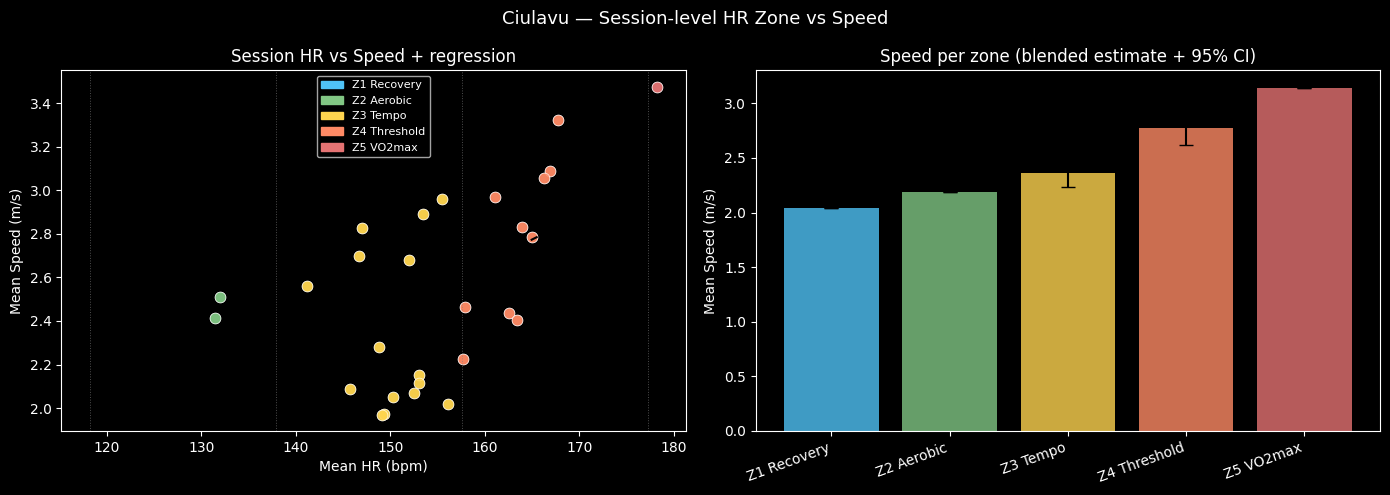

In [66]:
from scipy import stats as scipy_stats

BLEND_K   = 8    # crossover point: at n=8 empirical weight = 50%
MIN_SPEED = 1.5  # physiological floor — regression can't predict below this
MIN_N_CI  = 3    # minimum sessions to compute variance

def fmt_pace(speed_ms):
    pace = 1000 / speed_ms / 60
    mins = int(pace)
    secs = round((pace - mins) * 60)
    if secs == 60:       # carry-over guard
        mins += 1
        secs = 0
    return f'{mins}:{secs:02d} min/km'

# ── Linear regression: speed ~ mean_hr (personal aerobic profile) ───────────
reg = scipy_stats.linregress(session_stats['mean_hr'], session_stats['mean_speed'])
print(f'Regression  speed = {reg.slope:.4f} × HR + {reg.intercept:.3f}  '
      f'(R²={reg.rvalue**2:.2f}, p={reg.pvalue:.3f})')
print(f'Interpretation: {abs(reg.slope)*10:.3f} m/s per 10 bpm  '
      f'({"faster" if reg.slope > 0 else "slower"} with higher HR)\n')

hr_data_min = session_stats['mean_hr'].min()
hr_data_max = session_stats['mean_hr'].max()

def reg_predict(hr):
    hr_clamped = np.clip(hr, hr_data_min, hr_data_max)
    return max(reg.slope * hr_clamped + reg.intercept, MIN_SPEED)

# ── Blended zone estimates + 95% CI ─────────────────────────────────────────
zone_mid_hr = {
    z: (ZONE_BOUNDS[i] + ZONE_BOUNDS[i+1]) / 2 * MAX_HR
    for i, z in enumerate(ZONE_LABELS)
}

zone_estimates = {}
for z in ZONE_LABELS:
    subset   = session_stats[session_stats['hr_zone'] == z]['mean_speed'].dropna()
    n        = len(subset)
    reg_pred = reg_predict(zone_mid_hr[z])

    if n == 0:
        est    = reg_pred
        ci_lo  = ci_hi = ci_hw = None
        source = 'regression'
    else:
        emp_mean = subset.mean()
        w_emp    = n / (n + BLEND_K)
        est      = w_emp * emp_mean + (1 - w_emp) * reg_pred

        # CI only when blend is ≥50% empirical — below that it doesn't
        # bracket the blended estimate and is misleading to display.
        if n >= BLEND_K and n >= MIN_N_CI:
            se     = subset.std(ddof=1) / np.sqrt(n)
            t_crit = scipy_stats.t.ppf(0.975, df=n - 1)
            ci_lo  = emp_mean - t_crit * se
            ci_hi  = emp_mean + t_crit * se
            ci_hw  = (ci_hi - ci_lo) / 2
        else:
            ci_lo = ci_hi = ci_hw = None

        source = 'empirical' if n >= BLEND_K else f'blend ({w_emp:.0%} emp)'

    zone_estimates[z] = {
        'n': n, 'speed': est,
        'ci_lo': ci_lo, 'ci_hi': ci_hi, 'ci_hw': ci_hw,
        'source': source
    }

# ── Enforce monotonicity ─────────────────────────────────────────────────────
prev_speed = 0.0
for z in ZONE_LABELS:
    if zone_estimates[z]['speed'] < prev_speed:
        zone_estimates[z]['speed'] = prev_speed
        zone_estimates[z]['ci_lo'] = zone_estimates[z]['ci_hi'] = zone_estimates[z]['ci_hw'] = None
        zone_estimates[z]['source'] += ' [mono-corrected]'
    prev_speed = zone_estimates[z]['speed']

# ── Print summary ────────────────────────────────────────────────────────────
print(f'{"Zone":<20s} {"n":>4}  {"Speed (m/s)":>12}  {"Pace":>10}  {"95% CI (pace)":>24}  Source')
print('-' * 90)
for z in ZONE_LABELS:
    e      = zone_estimates[z]
    ci_str = (f'[{fmt_pace(e["ci_hi"])}, {fmt_pace(e["ci_lo"])}]'
              if e['ci_lo'] is not None else '           —')
    flag   = '  ⚠ low n' if 0 < e['n'] < BLEND_K else ''
    print(f'{z:<20s} {e["n"]:>4}  {e["speed"]:>7.2f} m/s  {fmt_pace(e["speed"]):>10}  {ci_str:>24}  {e["source"]}{flag}')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{ATHLETE_NAME} — Session-level HR Zone vs Speed', fontsize=13)

for z, c in zip(ZONE_LABELS, ZONE_COLORS):
    sub = session_stats[session_stats['hr_zone'] == z]
    axes[0].scatter(sub['mean_hr'], sub['mean_speed'], c=c, s=60, alpha=0.8,
                    edgecolors='white', linewidths=0.5, label=z)
hr_range = np.linspace(hr_data_min, hr_data_max, 100)
axes[0].plot(hr_range, reg.slope * hr_range + reg.intercept,
             color='black', lw=1.5, ls='--', label='regression')
for b in ZONE_BOUNDS[1:-1]:
    axes[0].axvline(b * MAX_HR, color='grey', lw=0.7, ls=':', alpha=0.6)
axes[0].set_xlabel('Mean HR (bpm)')
axes[0].set_ylabel('Mean Speed (m/s)')
axes[0].set_title('Session HR vs Speed + regression')
handles = [mpatches.Patch(color=c, label=z) for z, c in zip(ZONE_LABELS, ZONE_COLORS)]
axes[0].legend(handles=handles, fontsize=8)

speeds  = [zone_estimates[z]['speed'] for z in ZONE_LABELS]
ci_errs = [zone_estimates[z]['ci_hw'] or 0 for z in ZONE_LABELS]
axes[1].bar(ZONE_LABELS, speeds, color=ZONE_COLORS, alpha=0.8,
            yerr=ci_errs, capsize=5, error_kw=dict(ecolor='black', lw=1.5))
axes[1].set_xticklabels(ZONE_LABELS, rotation=20, ha='right')
axes[1].set_ylabel('Mean Speed (m/s)')
axes[1].set_title('Speed per zone (blended estimate + 95% CI)')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/hr_zone_vs_speed.png', dpi=150)
plt.show()

## Best effort predictions — 1k and 3k

In [67]:
def fmt_time(seconds):
    mins = int(seconds // 60)
    secs = round(seconds % 60)
    if secs == 60:
        mins += 1; secs = 0
    return f'{mins}:{secs:02d}'

# ── Zone-model predictions ───────────────────────────────────────────────────
hr_1k = 0.97 * MAX_HR
hr_3k = 0.93 * MAX_HR

speed_1k_pred = reg_predict(hr_1k)
speed_3k_pred = reg_predict(hr_3k)

time_1k_pred = 1000 / speed_1k_pred
time_3k_pred = 3000 / speed_3k_pred

hr_ceiling_pct = hr_data_max / MAX_HR * 100
clamped = hr_1k > hr_data_max
print('── Zone-model predictions ──────────────────────────────')
print(f'  Observed HR ceiling : {hr_data_max:.0f} bpm ({hr_ceiling_pct:.0f}% HRmax)')
if clamped:
    print(f'  ⚠ Both 97% and 93% HRmax exceed observed ceiling — predictions are clamped.')
    print(f'    Model cannot extrapolate to race effort. Results are lower-bound estimates only.')
print(f'  1k  (@ {hr_1k:.0f} bpm / 97% HRmax)  →  {fmt_time(time_1k_pred)}  ({fmt_pace(speed_1k_pred)})')
print(f'  3k  (@ {hr_3k:.0f} bpm / 93% HRmax)  →  {fmt_time(time_3k_pred)}  ({fmt_pace(speed_3k_pred)})')

# ── Empirical best efforts ────────────────────────────────────────────────────
BOUNDS = {
    1000: (150, 600),
    3000: (480, 1800),
}
MAX_SEGMENT_SPEED_MS = 7.0
MAX_RECORD_GAP_S     = 60

def best_effort(session_df, distance_m):
    min_s, max_s = BOUNDS[distance_m]
    df = (session_df
          .sort_values('timestamp')
          .dropna(subset=['distance', 'heart_rate'])
          .query('speed_ms >= 1.5')
          .reset_index(drop=True))

    t0 = df['timestamp'].min()
    df = df[df['timestamp'] >= t0 + pd.Timedelta(seconds=120)].reset_index(drop=True)

    if df.empty or df['distance'].max() - df['distance'].min() < distance_m:
        return None

    dists = df['distance'].values
    times = df['timestamp'].values
    hrs   = df['heart_rate'].values

    time_gaps    = np.diff(times) / np.timedelta64(1, 's')
    dist_deltas  = np.diff(dists)
    implied_spds = np.where(time_gaps > 0, dist_deltas / time_gaps, 0)

    best_s       = np.inf
    best_avg_hr  = None
    best_peak_hr = None
    j = 0

    for i in range(len(df)):
        while j < len(df) and dists[j] - dists[i] < distance_m:
            j += 1
        if j >= len(df):
            break

        elapsed = (times[j] - times[i]) / np.timedelta64(1, 's')
        if not (min_s <= elapsed <= max_s):
            continue

        segment_gaps = time_gaps[i:j]
        segment_spds = implied_spds[i:j]
        if len(segment_gaps) == 0:
            continue
        if segment_gaps.max() > MAX_RECORD_GAP_S:
            continue
        if segment_spds.max() > MAX_SEGMENT_SPEED_MS:
            continue

        if elapsed < best_s:
            best_s       = elapsed
            seg_hrs      = hrs[i:j]
            best_avg_hr  = seg_hrs.mean()
            best_peak_hr = np.percentile(seg_hrs, 95)   # 95th pct — ignores cardiac lag ramp

    return (best_s, best_avg_hr, best_peak_hr) if best_s < np.inf else None

results_1k, results_3k = [], []
for sid, grp in run_rec.groupby('session_id'):
    r1 = best_effort(grp, 1000)
    r3 = best_effort(grp, 3000)
    if r1: results_1k.append(r1)
    if r3: results_3k.append(r3)

best_1k = min(results_1k, key=lambda x: x[0]) if results_1k else None
best_3k = min(results_3k, key=lambda x: x[0]) if results_3k else None

print('\n── Empirical best efforts ──────────────────────────────')
print(f'  {"":6s}  {"Time":>6}  {"Pace":>10}  {"Avg HR":>8}  {"Peak HR (p95)":>14}  {"% HRmax (peak)":>15}')
if best_1k:
    s, avg_hr, peak_hr = best_1k
    print(f'  {"1k":6s}  {fmt_time(s):>6}  {fmt_pace(1000/s):>10}  {avg_hr:>7.0f}  {peak_hr:>14.0f}  {peak_hr/MAX_HR*100:>14.0f}%')
else:
    print('  1k  no valid segment found')

if best_3k:
    s, avg_hr, peak_hr = best_3k
    print(f'  {"3k":6s}  {fmt_time(s):>6}  {fmt_pace(3000/s):>10}  {avg_hr:>7.0f}  {peak_hr:>14.0f}  {peak_hr/MAX_HR*100:>14.0f}%')
else:
    print('  3k  no valid segment found')

print('\n── Comparison (total time) ─────────────────────────────')
if best_1k:
    diff = best_1k[0] - time_1k_pred
    print(f'  1k  model vs empirical:  {fmt_time(time_1k_pred)} vs {fmt_time(best_1k[0])}  ({"+" if diff>0 else ""}{fmt_time(abs(diff))} {"slower" if diff>0 else "faster"} than model)')
if best_3k:
    diff = best_3k[0] - time_3k_pred
    print(f'  3k  model vs empirical:  {fmt_time(time_3k_pred)} vs {fmt_time(best_3k[0])}  ({"+" if diff>0 else ""}{fmt_time(abs(diff))} {"slower" if diff>0 else "faster"} than model)')

── Zone-model predictions ──────────────────────────────
  Observed HR ceiling : 178 bpm (90% HRmax)
  ⚠ Both 97% and 93% HRmax exceed observed ceiling — predictions are clamped.
    Model cannot extrapolate to race effort. Results are lower-bound estimates only.
  1k  (@ 191 bpm / 97% HRmax)  →  5:27  (5:27 min/km)
  3k  (@ 183 bpm / 93% HRmax)  →  16:20  (5:27 min/km)

── Empirical best efforts ──────────────────────────────
            Time        Pace    Avg HR   Peak HR (p95)   % HRmax (peak)
  1k        4:54  4:54 min/km      170             187              95%
  3k       16:36  5:32 min/km      170             187              95%

── Comparison (total time) ─────────────────────────────
  1k  model vs empirical:  5:27 vs 4:54  (0:33 faster than model)
  3k  model vs empirical:  16:20 vs 16:36  (+0:16 slower than model)


In [68]:
# Which session did each best effort come from?
def find_source_session(run_rec, runs, distance_m, target_time):
    for sid, grp in run_rec.groupby('session_id'):
        result = best_effort(grp, distance_m)
        if result and abs(result[0] - target_time) < 1:
            info = runs[runs['session_id'] == sid].iloc[0]
            return sid, info['date'], info['distance_m'], info['duration_s']
    return None

if best_1k:
    r = find_source_session(run_rec, runs, 1000, best_1k[0])
    if r:
        sid, date, dist, dur = r
        print(f'1k best  →  session {sid}  |  {pd.Timestamp(date).date()}  |  total {dist/1000:.1f} km  |  {fmt_time(dur)}')

if best_3k:
    r = find_source_session(run_rec, runs, 3000, best_3k[0])
    if r:
        sid, date, dist, dur = r
        print(f'3k best  →  session {sid}  |  {pd.Timestamp(date).date()}  |  total {dist/1000:.1f} km  |  {fmt_time(dur)}')

1k best  →  session 115  |  2026-03-30  |  total 6.0 km  |  44:37
3k best  →  session 115  |  2026-03-30  |  total 6.0 km  |  44:37


In [69]:
# Verify segment HR is not accidentally the full session HR
def hr_audit(session_df, distance_m, target_time):
    min_s, max_s = BOUNDS[distance_m]
    df = (session_df
          .sort_values('timestamp')
          .dropna(subset=['distance', 'heart_rate'])
          .query('speed_ms >= 1.5')
          .reset_index(drop=True))

    t0 = df['timestamp'].min()
    df = df[df['timestamp'] >= t0 + pd.Timedelta(seconds=120)].reset_index(drop=True)

    dists = df['distance'].values
    times = df['timestamp'].values
    hrs   = df['heart_rate'].values

    time_gaps    = np.diff(times) / np.timedelta64(1, 's')
    dist_deltas  = np.diff(dists)
    implied_spds = np.where(time_gaps > 0, dist_deltas / time_gaps, 0)

    j = 0
    for i in range(len(df)):
        while j < len(df) and dists[j] - dists[i] < distance_m:
            j += 1
        if j >= len(df):
            break
        elapsed = (times[j] - times[i]) / np.timedelta64(1, 's')
        if not (min_s <= elapsed <= max_s):
            continue
        if len(time_gaps[i:j]) == 0:
            continue
        if time_gaps[i:j].max() > MAX_RECORD_GAP_S:
            continue
        if implied_spds[i:j].max() > MAX_SEGMENT_SPEED_MS:
            continue
        if abs(elapsed - target_time) < 1:
            seg_hrs = hrs[i:j]
            return {
                'segment_records'   : len(seg_hrs),
                'session_records'   : len(hrs),
                'segment_avg_hr'    : seg_hrs.mean(),
                'segment_min_hr'    : seg_hrs.min(),
                'segment_max_hr'    : seg_hrs.max(),
                'session_avg_hr'    : hrs.mean(),
                'start_dist'        : dists[i],
                'end_dist'          : dists[j],
                'start_time'        : pd.Timestamp(times[i]),
                'end_time'          : pd.Timestamp(times[j]),
            }
    return None

for label, distance_m, best in [('1k', 1000, best_1k), ('3k', 3000, best_3k)]:
    if not best:
        continue
    for sid, grp in run_rec.groupby('session_id'):
        result = best_effort(grp, distance_m)
        if result and abs(result[0] - best[0]) < 1:
            audit = hr_audit(grp, distance_m, best[0])
            if audit:
                print(f'── {label} segment audit ────────────────────────────────')
                print(f'  Records in segment  : {audit["segment_records"]}  (of {audit["session_records"]} session records)')
                print(f'  Distance            : {audit["start_dist"]:.0f}m → {audit["end_dist"]:.0f}m')
                print(f'  Time                : {audit["start_time"].strftime("%H:%M:%S")} → {audit["end_time"].strftime("%H:%M:%S")}')
                print(f'  Segment HR          : avg {audit["segment_avg_hr"]:.0f}  min {audit["segment_min_hr"]:.0f}  max {audit["segment_max_hr"]:.0f} bpm')
                print(f'  Full session HR avg : {audit["session_avg_hr"]:.0f} bpm')
                print()

── 1k segment audit ────────────────────────────────
  Records in segment  : 294  (of 1654 session records)
  Distance            : 1533m → 2535m
  Time                : 08:09:14 → 08:14:08
  Segment HR          : avg 170  min 116  max 187 bpm
  Full session HR avg : 167 bpm

── 1k segment audit ────────────────────────────────
  Records in segment  : 294  (of 1654 session records)
  Distance            : 1533m → 2535m
  Time                : 08:09:14 → 08:14:08
  Segment HR          : avg 170  min 116  max 187 bpm
  Full session HR avg : 167 bpm

── 3k segment audit ────────────────────────────────
  Records in segment  : 996  (of 1654 session records)
  Distance            : 1533m → 4535m
  Time                : 08:09:14 → 08:25:50
  Segment HR          : avg 170  min 116  max 195 bpm
  Full session HR avg : 167 bpm

── 3k segment audit ────────────────────────────────
  Records in segment  : 996  (of 1654 session records)
  Distance            : 1533m → 4535m
  Time                :